## Tutorial 1 - Intro

This tutorial introduces the basics of the software, defining the two objects necessary in all heat simulations: 
1) Beam
2) Medium

**NOTE**: The majority of the software uses SI units and eV for energy. This may be strange to work with for specific values (i.e. density). 

#### **BEAM**
To start, let's work with the 'Beam' class

In [5]:
from Beam import Beam
I = 0.2e-6/1.602e-19 # s^-1
E = 5e6 # eV

The Beam class takes intensity in units of s^-1 and energy in units of MeV.
There are 5 types of beam types:
1) Rectangular 
2) Circular
3) Gaussian
4) Annular
5) Gaussian + Annular
    
We will start by defining a hydrogen rectangular particle beam in 2D

In [6]:
Z = 1 # Atomic number 
dimension = 2 # Beam can be 2D or 3D
L = 1e-3 # Meters
W = 1e-3 # Meters
beam = Beam(E, I, Z, dimension, L = L, W = W)

The code will automatically determine the beam type based on the given inputs. 

The beam object has one primary method that calculates the power density. This method takes in (x, y, z) coordinates (meters) and outputs the power density at that point. Additionally, angles (alpha, beta) specify the beam divergence in the y and z directions, respectively. 

This method on its own is not particularly useful, but the simulation functions use this to calculate the volumetric heating by the beam.

#### **MEDIUM**
Next, we will look at the 'Medium' object. These objects hold the material properties (rho, C, k) and atomic compositions of the irradiation targets. 

Let's create a medium of pure aluminum. To start, we will need to define the material composition by creating an 'Atom' object.

In [7]:
from Medium import Atom, Medium

name = 'Al'
atomic_fraction = 1 # percentange (out of 1)
Z_Al = 13
A_Al = 27 # Given in g/mol

Al_atom = Atom(name, atomic_fraction, Z_Al, A_Al)

For more complex materials, a list of Atoms should be created instead and passed into the Medium object. 

To define the Medium, a stopping power table from SRIM must be provided in '.txt' format. Ensure that the table covers a sufficient range of energies (1eV to 10MeV should be good enough), otherwise some odd behaviours might occur. 

**NOTE**: The units for the SRIM tables do not matter, the software will automatically convert them to SI.  

For the simplest case, which is a 2D rectangular block, we will also need to provide the material dimensions and initial position along the beam axis (x). 


In [8]:
SRIM_fileName = "Al//Hydrogen in Aluminum.txt" # relative path or absolute path
rho_Al = 2700 # Density in kg/m^3
C_Al = 900 # Specific heat capacity in J/(kg*K)
k_Al = 205.0 # Heat conductivity in W/(m*K)
Lx_Al = 5e-2 # [m]
Ly_Al = 2e-2 
x0_Al = 0 

aluminum = Medium(rho_Al, C_Al, k_Al, Al_atom, SRIM_fileName,
                  Lx = Lx_Al, Ly = Ly_Al, x0 = x0_Al, name = 'Aluminum') 

Using get_Se_ev_m(E) or get_Se_ev_m_atom(E) returns the stopping power of the material at the specified energy value.  There are more methods which the simulation uses, but showing them here is not particularly important. 

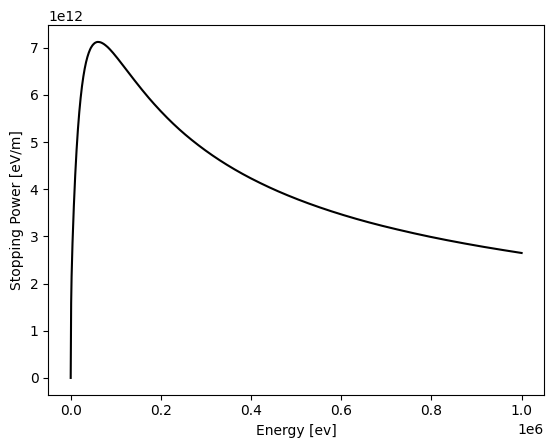

In [9]:
import numpy as np
import matplotlib.pyplot as plt

Es = np.linspace(0, 1e6, 1000)
Se = aluminum.get_Se_ev_m(Es)

plt.plot(Es, Se, 'k')
plt.xlabel('Energy [ev]')
plt.ylabel('Stopping Power [eV/m]')
plt.show()

Temperature dependant material properties can also be passed into the Medium class. For this, we need to define functions f(T). 

**Note**: Ensure that any operations you perform in the function use NUMERIX and not NUMPY

In [ ]:
# !pip install fipy # run this if fipy isn't recognized

In [17]:
from fipy.tools import numerix as nx
def k_Al(T):
    T_safe = nx.clip(T, 0, 2200)     # Always prevent T from going below 0
    return nx.maximum(2.5*T_safe**3, 1.0)     # Final safety floor (k should never be 0 or negative)

def C_Al(T):
    T_safe = nx.clip(T, 0, 2200) 
    return nx.maximum(T_safe**3, 1.0)

aluminum = Medium(rho_Al, C_Al, k_Al, Al_atom, SRIM_fileName,
                  Lx = Lx_Al, Ly = Ly_Al, x0 = x0_Al, name = 'Aluminum') 

The simulation will then call accessor methods within the object to update 

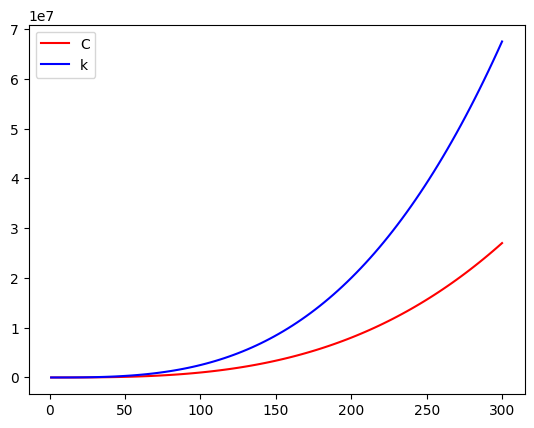

In [18]:
Ts = np.linspace(1, 300, 100)
Cs = aluminum.get_C(Ts)
ks = aluminum.get_k(Ts)

plt.plot(Ts, Cs, 'r', label= 'C')
plt.plot(Ts, ks, 'b', label = 'k')
plt.legend()
plt.show()

#### That's it! These two objects + boundary conditions are all you need to start heating simulations. 